## Final Project Submission

Please fill out:
* Student name: Peris Kigo
* Student pace: full time
* Scheduled project review date/time:30/06/25
* Instructor name: William Okomba
* Blog post URL:



# Phase_1 Project - Aviation Analysis.
The company wants to expand into the aviation industry to diversify its portfolio. They are specifically interested in purchasing and operating airplanes, but they are unsure which aircraft are the safest investment.

## Problem statement.
Without the company understanding which aircraft are most frequently involved in accidents, the company risks making costly and potentially dangerous decisions. To support a safe and successful entry into this industry, there is  a need to analyze the data given to identify which aircraft to purchase to help the company make informed and data-driven decisions.
## Goals.
To use the data to help minimize operational risk by selecting Aircraft with the lowest incidents or accidents.
## Project scope.
* Understand what factors contribute to the accidents.
* compare different aircraft types based on the accidents.
* Identify aircraft with the lowest incident rates

# Data Understanding.
The dataset was provided by the National Transportation Safety Board. It contains the aviation accident data from 1962 to 2023 about civil aviation accidents. The data was shared as part of this project and is stored locally in the folder.
The file is provided in a **CSV** format.
> ###      **'Aviation_Data.CSV'**


In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv ('AviationData.csv', encoding = 'cp1252', low_memory = False )

In [3]:
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [4]:
df.tail()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88888,20221230106513,Accident,ERA23LA097,2022-12-29,"Athens, GA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,1.0,NaN,NaN,NaN,30-12-2022


__*Observation*:__ The dataset is uniform from top to bottom

In [5]:
df.shape

(88889, 31)

__*Observation*:__ The dataset comprises of 88,889 records and 31 columns

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

__*Observation*:__ The dataset comprises of 5 numerical columns and 26 categorical columns.

In [7]:
df.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


__*Observation*__: The injury data is heavily skewed with low or zero value and a few extreme values.

In [8]:
df.describe(include = 'O').T

,count,unique,top,freq
Event.Id,88889,87951,20001212X19172,3
Investigation.Type,88889,2,Accident,85015
Accident.Number,88889,88863,CEN22LA149,2
Event.Date,88889,14782,1984-06-30,25
Location,88837,27758,"ANCHORAGE, AK",434
Country,88663,219,United States,82248
Latitude,34382,25589,332739N,19
Longitude,34373,27154,0112457W,24
Airport.Code,50132,10374,NONE,1488
Airport.Name,52704,24870,Private,240


In [9]:
df1 = df.copy(deep = True)
df1[:3]

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007


In [10]:
for coln in df1:
    coln_val = df1[coln].unique()
    print(f'{coln}\n{coln_val}\n')

Event.Id
['20001218X45444' '20001218X45447' '20061025X01555' ... '20221227106497'
 '20221227106498' '20221230106513']

Investigation.Type
['Accident' 'Incident']

Accident.Number
['SEA87LA080' 'LAX94LA336' 'NYC07LA005' ... 'WPR23LA075' 'WPR23LA076'
 'ERA23LA097']

Event.Date
['1948-10-24' '1962-07-19' '1974-08-30' ... '2022-12-22' '2022-12-26'
 '2022-12-29']

Location
['MOOSE CREEK, ID' 'BRIDGEPORT, CA' 'Saltville, VA' ... 'San Manual, AZ'
 'Auburn Hills, MI' 'Brasnorte, ']

Country
['United States' nan 'GULF OF MEXICO' 'Puerto Rico' 'ATLANTIC OCEAN'
 'HIGH ISLAND' 'Bahamas' 'MISSING' 'Pakistan' 'Angola' 'Germany'
 'Korea, Republic Of' 'Martinique' 'American Samoa' 'PACIFIC OCEAN'
 'Canada' 'Bolivia' 'Mexico' 'Dominica' 'Netherlands Antilles' 'Iceland'
 'Greece' 'Guam' 'Australia' 'CARIBBEAN SEA' 'West Indies' 'Japan'
 'Philippines' 'Venezuela' 'Bermuda' 'San Juan Islands' 'Colombia'
 'El Salvador' 'United Kingdom' 'British Virgin Islands' 'Netherlands'
 'Costa Rica' 'Mozambique' 'Jama

__*Observation*:__ The dataset has a lot of nan values and unknown values

In [11]:
df1.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [12]:
df.replace(['UNK' , 'Unknown' , 'Unk' , 'nan' , 'NONE'],np.nan, inplace = True)

In [13]:
df1.isnull().sum()

Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     52
Country                     226
Latitude                  54507
Longitude                 54516
Airport.Code              38757
Airport.Name              36185
Injury.Severity            1000
Aircraft.damage            3194
Aircraft.Category         56602
Registration.Number        1382
Make                         63
Model                        92
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                7096
FAR.Description           56866
Schedule                  76307
Purpose.of.flight          6192
Air.carrier               72241
Total.Fatal.Injuries      11401
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Uninjured            5912
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6384
Publication.Date          13771
dtype: i

__*Observation*:__ Several columns contained inconcistent representation of missing values
* These were standardised by replacing them with actual null values

In [14]:
df1[['Make' , 'Model']].isnull().sum()

Make     63
Model    92
dtype: int64

In [15]:
df1[df1['Make'].isnull() | df1['Model'].isnull()]

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
354,20020917X02286,Accident,LAX82FUA11,1982-02-19,"TORRANCE, CA",United States,NaN,NaN,TOA,TORRANCE,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,Landing,Probable Cause,19-02-1983
443,20020917X02032,Accident,FTW82DA082,1982-02-28,"TAYLOR, TX",United States,NaN,NaN,T74,TAYLOR MUNICIPAL,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,Maneuvering,Probable Cause,28-02-1983
461,20020917X01674,Accident,ATL82DA063,1982-03-02,"BROWNSBORO, AL",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,0.0,1.0,0.0,VMC,Approach,Probable Cause,02-03-1983
835,20020917X02071,Accident,FTW82DA129,1982-04-14,"CLEVELAND, TX",United States,NaN,NaN,6R3,CLEVELAND MUNICIPAL,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,Takeoff,Probable Cause,14-04-1983
1637,20020917X03452,Accident,FTW82FPD13,1982-06-20,"ROANOKE, TX",United States,NaN,NaN,NaN,AERO VALLEY,...,Personal,NaN,1.0,1.0,0.0,0.0,VMC,Maneuvering,Probable Cause,20-06-1983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73592,20130531X43222,Incident,DCA13WA097,2013-05-22,"Panama City, Panama",Panama,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,90.0,NaN,NaN,NaN,03-11-2020
73617,20130808X52306,Incident,CEN13WA470,2013-05-26,"Geneva, Eswatini",Eswatini,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,VMC,NaN,NaN,03-11-2020
74873,20140327X61657,Accident,ERA14LA174,2014-03-26,"Patillas, PR",United States,175831N,0066115W,X64,Patillas Airport,...,Personal,Emerito Guzman,1.0,0.0,0.0,0.0,VMC,NaN,The pilot’s failure to maintain airplane contr...,25-09-2020
77653,20151222X23224,Incident,DCA16WA034,2015-12-04,"Perth, Australia",Australia,NaN,NaN,NaN,NaN,...,NaN,Scoot Air,0.0,0.0,0.0,0.0,NaN,NaN,NaN,25-09-2020


In [16]:
df.dropna(subset=['Make' , 'Model'], inplace=True)

__*Observation*:__ 112 rows had missingvalues in either make or model columns of which they were dropped 

In [17]:
df1['Aircraft.damage']=df1['Aircraft.damage'].astype(str).str.strip().str.upper()
df1['Make']= df1['Make'].astype(str).str.strip().str.upper()
df1['Model']=df1['Model'].astype(str).str.strip().str.upper()
df1['aircraft_type'] = df1['Make'].fillna('UNKNOWN') + '' + df1['Model'].fillna('UNKNOWN')

__*Observation*:__ Cleaning of the categorical columns
* The data had different entries of the columns with different formattings, so it had to be standardized.
* Make and model was grouped in 'aircraft-type'

In [18]:
most_used_aircraft = df1['aircraft_type'].value_counts()
most_used_aircraft.reset_index()

,aircraft_type,count
0,CESSNA152,2366
1,CESSNA172,1753
2,CESSNA172N,1163
3,PIPERPA-28-140,932
4,CESSNA150,829
...,...,...
18292,ROE-WAYNEMUSTANG II,1
18293,SPENCERPITTS S-1S,1
18294,WOLFSMITH M/P DSA-1,1
18295,BOEING737-548,1


__*Observation*:__ CESSNA 152 is the most common aircraft

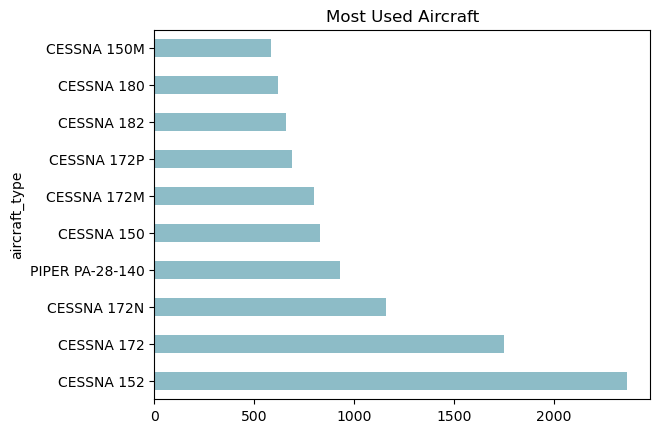

In [82]:
most_used_aircraft = df1['aircraft_type'].value_counts()
most_used_aircraft.head(10).plot(kind='barh',x='aircraft_type',
                                               title='Most Used Aircraft', color='#8DBCC7')
plt.savefig('images/Most_Used_Aircraft.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
least_used_aircraft = df1['aircraft_type'].value_counts(ascending=True)
least_used_aircraft.reset_index()

,aircraft_type,count
0,CHRISTIANQUICKSILVER,1
1,PEARSONSUPERFLY,1
2,VELTMANCH701,1
3,SCHEMPP-HIRTHDISCUS-2CT,1
4,STAMPESV-4C,1
...,...,...
18292,CESSNA150,829
18293,PIPERPA-28-140,932
18294,CESSNA172N,1163
18295,CESSNA172,1753


__*Observation*:__ CHRISTIANQUICKSILVER is the least used aircraft

In [21]:
df1['Event.Date'] = pd.to_datetime(df1['Event.Date'], errors='coerce')
df1['year'] = df1['Event.Date'].dt.year
accidents_per_year = df1['year'].value_counts().sort_index()
accidents_per_year.head(20).reset_index()

,year,count
0,1948,1
1,1962,1
2,1974,1
3,1977,1
4,1979,2
5,1981,1
6,1982,3593
7,1983,3556
8,1984,3457
9,1985,3096


__*Observation*:__ Most of the accidents from the data begin at 1982 going on.

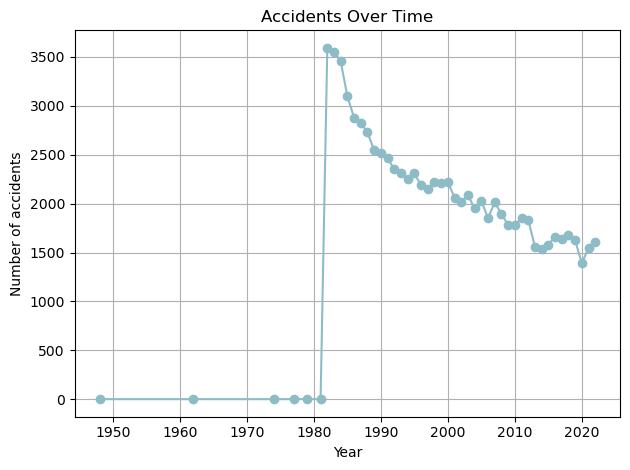

In [84]:
accidents_per_year.plot(kind='line', marker='o', title='Accidents Over Time', color='#8DBCC7')
plt.xlabel('Year')
plt.ylabel('Number of accidents')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/Accidents_Over_Time.png', dpi=300, bbox_inches='tight')
plt.show()

__*Observation*:__ The number of accidents is dropping over the years.

In [23]:
for coln in ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries']:
    df1[coln] = pd.to_numeric(df1[coln], errors='coerce').fillna(0)
df1['total_injuries'] = df1[['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries']].sum(axis=1)

* Adding the sum of total fatal injuries, total serious injuries and total minor injuries into the total injuries dataframe. 

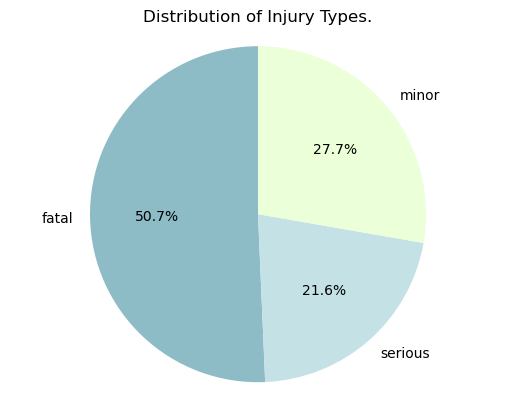

In [24]:
injury_sums = {'fatal' :df1['Total.Fatal.Injuries'].sum(),
               'serious' :df1['Total.Serious.Injuries'].sum(),
               'minor' : df1['Total.Minor.Injuries'].sum()
}
plt.pie(injury_sums.values(), labels=injury_sums.keys(), autopct='%1.1f%%', startangle=90, colors=['#8DBCC7', '#C4E1E6', '#EBFFD8'])
plt.title('Distribution of Injury Types.')
plt.axis('equal')
plt.show()

__*Observation*:__ The fatal serious and minor injuries were grouped together.
* This dataset has more fatal injuries than minor and serious.

In [25]:
injuries_by_type = df1.groupby('aircraft_type')['total_injuries'].sum().reset_index()
injuries_by_type = injuries_by_type.sort_values(by = 'total_injuries', ascending = False)
injuries_by_type.head(10)

,aircraft_type,total_injuries
3221,BOEING737,1827.0
4679,CESSNA172,1100.0
3257,BOEING737-200,1064.0
4655,CESSNA152,1013.0
13487,PIPERPA-28-140,996.0
4730,CESSNA172N,975.0
13504,PIPERPA-28-181,676.0
4728,CESSNA172M,662.0
2586,BELL206B,629.0
13497,PIPERPA-28-180,607.0


__*Observation*:__ Boeing 737 is the airplane with the most number of total  injuries

In [26]:
injuries_by_type = injuries_by_type.sort_values(by = 'total_injuries', ascending = True)
injuries_by_type.tail(10)

,aircraft_type,total_injuries
13497,PIPERPA-28-180,607.0
2586,BELL206B,629.0
4728,CESSNA172M,662.0
13504,PIPERPA-28-181,676.0
4730,CESSNA172N,975.0
13487,PIPERPA-28-140,996.0
4655,CESSNA152,1013.0
3257,BOEING737-200,1064.0
4679,CESSNA172,1100.0
3221,BOEING737,1827.0


__*Observation*:__ PIPERPA-28-180 is the aircraft with the least number of total injuries

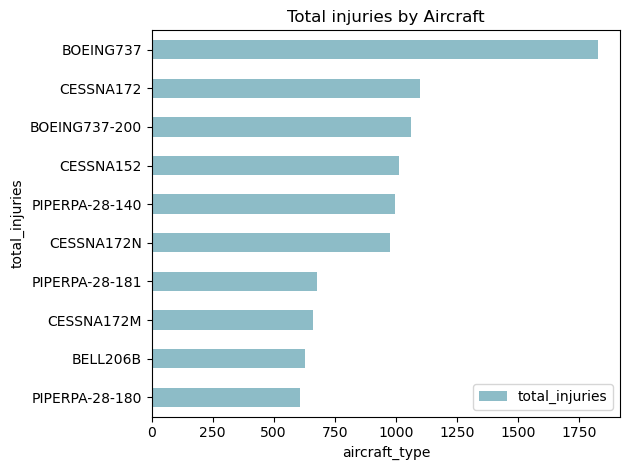

In [85]:
injuries_by_type.tail(10).plot(kind= 'barh',x='aircraft_type', y='total_injuries', color= '#8DBCC7')
plt.title('Total injuries by Aircraft')
plt.xlabel('aircraft_type')
plt.ylabel('total_injuries')
plt.tight_layout()
plt.savefig('images/Total_injuries_by_Aircraft.png', dpi=300, bbox_inches='tight')
plt.show()

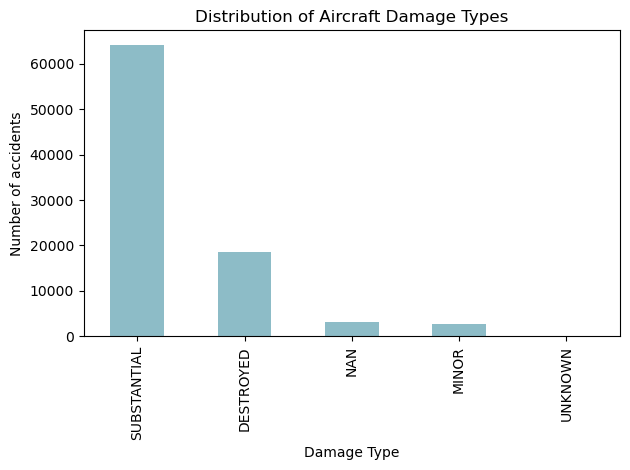

In [28]:
damage_counts = df1['Aircraft.damage'].value_counts()
damage_counts.plot(kind='bar' , color='#8DBCC7')

plt.title('Distribution of Aircraft Damage Types')
plt.xlabel('Damage Type')
plt.ylabel('Number of accidents')
plt.tight_layout()
plt.show()                   

In [77]:
# Group by aircraft type
group_coln = 'aircraft_type'

# Check columns per aircraft type
fatalities = df1.groupby(group_coln)['Total.Fatal.Injuries'].sum().reset_index(name='total_fatalities')
accidents = df1.groupby(group_coln)['Event.Id'].nunique().reset_index(name='total_accidents')
injuries = df1.groupby(group_coln)['total_injuries'].sum().reset_index(name='total_injuries')

# Mark aircraft damage as severe if its DESTROYED or SUBSTANTIAL
df1['severe'] = df1['Aircraft.damage'].isin(['DESTROYED', 'SUBSTANTIAL']).astype(int)

# Count how many severe damages occuured per aircraft type

severe = df1.groupby(group_coln)['severe'].sum().reset_index(name= 'severe_damage_count')

In [78]:
# Merge all dataframes to a single dataframe called Aircraft
table_df=[injuries, fatalities, severe, accidents]
Aircraft = table_df[0]
for d in table_df[1:]:
    Aircraft = pd.merge(Aircraft, d, on=group_coln ,how='outer')
Aircraft.fillna(0, inplace=True)

In [80]:
# Calculate the ratios needed
Aircraft['injury_ratio'] =  Aircraft['total_injuries'] / Aircraft ['total_accidents']
Aircraft['severe_damage_ratio'] = Aircraft['severe_damage_count'] / Aircraft ['total_accidents']

# Filter the aircraft type with 50 or more recorded accidents
Aircraft = Aircraft[Aircraft['total_accidents'] >=50]

# Sort
Aircraft = Aircraft.sort_values( by = ['total_accidents', 'total_fatalities', 'injury_ratio', 'severe_damage_ratio'],ascending=[True, True, True, True])
Aircraft[['aircraft_type', 'total_accidents', 'total_fatalities', 'injury_ratio', 'severe_damage_ratio']].head(10)

,aircraft_type,total_accidents,total_fatalities,injury_ratio,severe_damage_ratio
8769,GRUMMAN-SCHWEIZER G-164A,50,0.0,0.320000,0.980000
4600,CESSNA 150D,50,8.0,0.440000,1.000000
2623,BELL 47D1,50,9.0,0.600000,1.000000
5486,CHAMPION 7GCAA,50,12.0,0.600000,1.000000
13202,PIPER J3C,50,13.0,0.760000,0.960000
2400,BEECH K35,50,30.0,1.240000,0.980000
13407,PIPER PA-23,50,33.0,1.120000,0.960000
2291,BEECH C90,50,55.0,1.380000,0.920000
7307,ENSTROM F-28C,51,2.0,0.411765,0.960784
5478,CHAMPION 7EC,51,16.0,0.725490,1.000000


__*Observation*:__ GRUMMAN-SCHWEIZER G-164A and CESSNA 150D have the safest metrics

In [81]:
Aircraft[['aircraft_type', 'total_accidents', 'total_fatalities', 'injury_ratio', 'severe_damage_ratio']].tail(10)

,aircraft_type,total_accidents,total_fatalities,injury_ratio,severe_damage_ratio
4609,CESSNA 150M,585,103.0,0.548718,0.984615
4718,CESSNA 180,621,103.0,0.397746,0.991948
4742,CESSNA 182,659,218.0,0.804249,0.977238
4688,CESSNA 172P,687,238.0,0.822416,0.992722
4683,CESSNA 172M,798,243.0,0.829574,0.982456
4583,CESSNA 150,829,127.0,0.541616,0.977081
13461,PIPER PA-28-140,931,321.0,1.069817,0.990333
4685,CESSNA 172N,1163,428.0,0.838349,0.984523
4634,CESSNA 172,1752,398.0,0.627854,0.980594
4610,CESSNA 152,2357,390.0,0.429784,0.985151


In [34]:
df1.to_csv('cleaned_AviationData.csv')

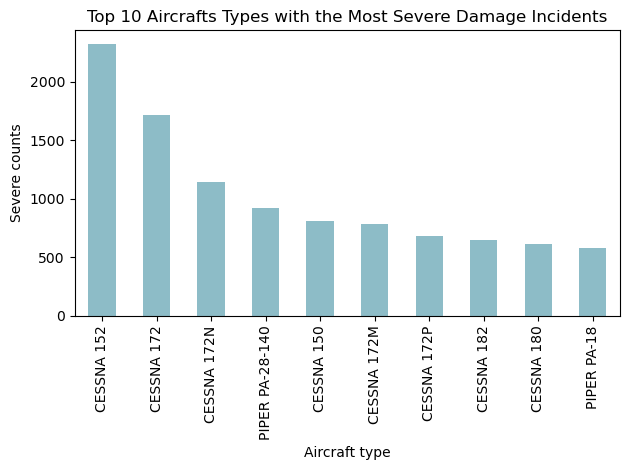

In [35]:
df1['aircraft_type'] = df1['Make'] + ' ' + df1['Model']
severe_df= df1[df1['Aircraft.damage'].isin(['DESTROYED', 'SUBSTANTIAL'])]
severe_counts= severe_df ['aircraft_type'].value_counts().sort_values(ascending= False).head(10)
severe_counts.plot(kind='bar', color='#8DBCC7')
plt.title('Top 10 Aircrafts Types with the Most Severe Damage Incidents')
plt.xlabel('Aircraft type')
plt.ylabel('Severe counts')
plt.tight_layout()
plt.show()